In [29]:
import unittest
import sys
import os
import copy
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt

sys.path.append("/Net/Groups/BSI/work_scratch/ppapastefanou/src/PlantHydraulicStandalone")
from src.contrib.swiss_tree_parser import SwissTreeParser
from src.contrib.auxil.setups import Setup
from src.contrib.auxil.output_df import create_output_df
from src.contrib.auxil.files import get_trees_psi_leaf_folder_path_cc
from src.contrib.config import Config, Swiss_soil_water_input_type

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2025_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_h_kxylem"

root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "09_ex_con_2025_full_logit_mean_one"


# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

setup = Setup()
setup.Apply_default_swiss(Swiss_soil_water_input_type.OneLayer_Mean_One_Std)
setup.Apply_default_paths(root_output_directory, scenario_name)
setup.config.parameters_list_file = os.path.join(setup.config.post_path, "parameters_best_mean_alive.csv")
setup.config.config_file = os.path.join("config_dummy.txt")
# Specifying forcing and evalution data paths
#setup.Export()

# Read in the Swiss trees
tree_parser = SwissTreeParser(get_trees_psi_leaf_folder_path_cc())

print(setup.config.build_folder)
sys.path.append("/Net/Groups/BSI/work_scratch/ppapastefanou/src/PlantHydraulicStandalone/build")
from SimPHony import Simulation_Single_Swiss
from SimPHony import DateTime

selective_range = ['mean_alive', 0,3, 6, 7]
#selective_range = [0, 4, 6, 7]
ax_indexes =[1,2,3,4,5]
N_BEST = 10

/Net/Groups/BSI/work_scratch/ppapastefanou/src/PlantHydraulicStandalone/src/contrib/auxil/../../../build


In [30]:
for id, ai in zip(selective_range, ax_indexes) :
    if ai == 1:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Alive.csv")
    else:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Dead{ai-1}.csv")
    print(pd.read_csv(setup.config.parameters_list_file).shape)

(5691, 73)
(5691, 73)
(5691, 73)
(5691, 73)
(5691, 73)


In [59]:
dead_ids =[0,3,6,7]
df_ax_m = {}
df_ax_ql = {}
df_ax_qu = {}

df_ax_m24 = {}
df_ax_ql24 = {}
df_ax_qu24 = {}

trees = {}
for id, ai in zip(selective_range, ax_indexes):

    if ai == 1:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Alive.csv")
    else:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Dead{ai-1}.csv")

    setup.Export()

    for j in range(0, 5000, int(5000/100)):

        # ----------------------------------------------------------------
        # PHS model simulation
        # ----------------------------------------------------------------

        # Specify Start and End of the Simulation
        format = "%Y-%m-%d %H:%M:%S"
        date_start_str = "2018-05-01 00:00:00"
        date_end_str = "2018-12-15 00:00:00"
        timestart = DateTime(date_start_str, format)
        timeend = DateTime(date_end_str, format)

        # Set up the PHS simulation
        # read in the parameter file that we just created
        sim = Simulation_Single_Swiss()
        sim.Read_config(setup.config.config_file)
        sim.Init_eval(timestart, timeend)
        sim.Init_parameters_fn_single(j)
        sim.Init_input()
        sim.Set_water_pot_initials(-1.0, -0.2)

        # Run the simulation
        sim.Run(timestart, timeend)
        sim.Analyse()

        # Get output and analysis data
        # output = sim.Get_output()
        an = sim.Get_analysis()
        errors = an.Get_rmse()

        # Getting the raw output data
        output = sim.Get_output()
        # Getting the raw analysis data
        an = sim.Get_analysis()
        

        # Creating pandas dataframe
        df_mod = create_output_df(output, date_start_str)

        df_mod['id'] = int(j)
        
        rmse = an.Get_rmse()
        if ai == 1:
            df_mod['rmse'] = np.mean(np.array(rmse)[[1, 4, 9, 10, 11, 12, 13]])
        else:
            df_mod['rmse'] = rmse[id]


        
        if j == 0:
            df_d = df_mod
        else:
            df_d = pd.concat([df_d, df_mod], axis=0)
        print(j)

    # ----------------------------------------------------------------
    # Plotting model output
    # ----------------------------------------------------------------

    if id == 'mean_alive':
        tree_df = tree_parser.df_alive_all
    else:
        tree_df = tree_parser.trees[id].df
      
    trees[ai] = tree_df   
    dm = df_d.groupby(df_d.index).median()
    d25 = df_d.groupby(df_d.index).quantile(0.1)
    d75 = df_d.groupby(df_d.index).quantile(0.9)

    df_ax_m[ai] = dm
    df_ax_ql[ai] = d25
    df_ax_qu[ai] = d75
    
    dfm = df_d.groupby([df_d.index.hour, df_d.index.minute]).mean()
    dfql = df_d.groupby([df_d.index.hour, df_d.index.minute]).quantile(0.1)
    dfqu = df_d.groupby([df_d.index.hour, df_d.index.minute]).quantile(0.9)
    
    df_ax_m24[ai] = dfm
    df_ax_ql24[ai] = dfql
    df_ax_qu24[ai] = dfqu


0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
2050
2100
2150
2200
2250
2300
2350
2400
2450
2500
2550
2600
2650
2700
2750
2800
2850
2900
2950
3000
3050
3100
3150
3200
3250
3300
3350
3400
3450
3500
3550
3600
3650
3700
3750
3800
3850
3900
3950
4000
4050
4100
4150
4200
4250
4300
4350
4400
4450
4500
4550
4600
4650
4700
4750
4800
4850
4900
4950
0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
2050
2100
2150
2200
2250
2300
2350
2400
2450
2500
2550
2600
2650
2700
2750
2800
2850
2900
2950
3000
3050
3100
3150
3200
3250
3300
3350
3400
3450
3500
3550
3600
3650
3700
3750
3800
3850
3900
3950
4000
4050
4100
4150
4200
4250
4300
4350
4400
4450
4500
4550
4600
4650
4700
4750
4800
4850
4900
4950
0
50
100
150
200
250
300
350
400
450
500
550
6

In [60]:
print(np.round(df_ax_ql[1]['rmse'].iloc[0],2))
print(np.round(df_ax_m[1]['rmse'].iloc[0],2))
print(np.round(df_ax_qu[1]['rmse'].iloc[0],2))


0.49
0.51
0.52


In [61]:
print(np.round(df_ax_ql[1]['psiLeaf'].mean(),2))
print(np.round(df_ax_m[1]['psiLeaf'].mean(),2))
print(np.round(df_ax_qu[1]['psiLeaf'].mean(),2))

-1.36
-1.25
-1.12


In [34]:
print(np.round(df_ax_ql[1]['psiSap'].mean(),2))
print(np.round(df_ax_m[1]['psiSap'].mean(),2))
print(np.round(df_ax_qu[1]['psiSap'].mean(),2))

-0.82
-0.73
-0.63


In [9]:
print(np.round(df_ax_ql[1]['psiSoilUp'].mean(),2))
print(np.round(df_ax_m[1]['psiSoilUp'].mean(),2))
print(np.round(df_ax_qu[1]['psiSoilUp'].mean(),2))

-0.82
-0.69
-0.52


In [10]:
print(np.round(df_ax_ql[1]['gss'].mean(),3))
print(np.round(df_ax_m[1]['gss'].mean(),3))
print(np.round(df_ax_qu[1]['gss'].mean(),3))

0.01
0.015
0.02


In [11]:
print(np.round(df_ax_m[1]['vpd'].mean(),2))

617.11


In [12]:
print(np.round(df_ax_ql[1]['T'].mean(),6))
print(np.round(df_ax_m[1]['T'].mean(),6))
print(np.round(df_ax_qu[1]['T'].mean(),6))

0.0001
0.000154
0.000215


In [13]:
print(np.round(df_ax_ql[1]['G'].mean(),6))
print(np.round(df_ax_m[1]['G'].mean(),6))
print(np.round(df_ax_qu[1]['G'].mean(),6))

9.3e-05
0.000154
0.000228


In [14]:
dfm = df_ax_m[1].groupby([df_ax_m[1].index.hour, df_ax_m[1].index.minute]).mean()
dfql = df_ax_ql[1].groupby([df_ax_ql[1].index.hour, df_ax_ql[1].index.minute]).mean()
dfqu = df_ax_qu[1].groupby([df_ax_qu[1].index.hour, df_ax_qu[1].index.minute]).mean()

In [15]:
df_ax_m24[1]

DeltaT          vpd       ksSoil0  psiSoilUp    psiSap  \
date date                                                              
0    0     9806400.0   423.307291  2.934268e-09  -0.679153 -0.717628   
     30    9808200.0   406.477329  2.938655e-09  -0.679479 -0.716516   
1    0     9810000.0   389.647363  2.943561e-09  -0.679822 -0.715406   
     30    9811800.0   374.269320  2.948999e-09  -0.680185 -0.714297   
2    0     9813600.0   358.891276  2.954980e-09  -0.680564 -0.713190   
     30    9815400.0   346.279453  2.948617e-09  -0.680139 -0.712161   
3    0     9817200.0   333.667631  2.942669e-09  -0.679743 -0.711172   
     30    9819000.0   322.745819  2.937148e-09  -0.679376 -0.710224   
4    0     9820800.0   311.824004  2.932065e-09  -0.679036 -0.709314   
     30    9822600.0   304.266448  2.927431e-09  -0.678723 -0.708542   
5    0     9824400.0   296.708889  2.923261e-09  -0.678435 -0.707874   
     30    9826200.0   300.871641  2.919565e-09  -0.678172 -0.707465   
6    0     9828000.0   305.034392  2.916359e-09  -0.677933 -0.707254   
     30    9829800.0   334.217175  2.913657e-09  -0.677718 -0.707356   
7    0     9831600.0   363.399956  2.911474e-09  -0.677524 -0.707673   
     30    9833400.0   408.419250  2.909828e-09  -0.677353 -0.708066   
8    0     9835200.0   453.438544  2.908734e-09  -0.677202 -0.708656   
     30    9837000.0   507.527773  2.908212e-09  -0.677072 -0.709465   
9    0     9838800.0   561.617006  2.908281e-09  -0.676962 -0.710454   
     30    9840600.0   621.628042  2.908960e-09  -0.676871 -0.711628   
10   0     9842400.0   681.639078  2.910272e-09  -0.676799 -0.712961   
     30    9844200.0   741.324837  2.912240e-09  -0.676745 -0.714459   
11   0     9846000.0   801.010598  2.914886e-09  -0.676709 -0.716093   
     30    9847800.0   855.458624  2.918236e-09  -0.676691 -0.717832   
12   0     9849600.0   909.906646  2.922318e-09  -0.676689 -0.719637   
     30    9851400.0   946.504919  2.927160e-09  -0.676704 -0.721496   
13   0     9853200.0   983.103192  2.932791e-09  -0.676735 -0.723380   
     30    9855000.0  1004.982444  2.939242e-09  -0.676782 -0.725268   
14   0     9856800.0  1026.861690  2.946548e-09  -0.676844 -0.727094   
     30    9858600.0  1040.109701  2.942368e-09  -0.676616 -0.728817   
15   0     9860400.0  1053.357709  2.938553e-09  -0.676428 -0.730363   
     30    9862200.0  1037.477477  2.935106e-09  -0.676278 -0.731609   
16   0     9864000.0  1021.597257  2.932035e-09  -0.676165 -0.732451   
     30    9865800.0   979.093984  2.929343e-09  -0.676086 -0.732943   
17   0     9867600.0   936.590722  2.927038e-09  -0.676040 -0.733016   
     30    9869400.0   878.173480  2.925124e-09  -0.676026 -0.732690   
18   0     9871200.0   819.756237  2.923609e-09  -0.676043 -0.731930   
     30    9873000.0   756.448876  2.922498e-09  -0.676089 -0.730884   
19   0     9874800.0   693.141523  2.921800e-09  -0.676164 -0.729545   
     30    9876600.0   645.265584  2.921519e-09  -0.676265 -0.728210   
20   0     9878400.0   597.389650  2.921665e-09  -0.676393 -0.726840   
     30    9880200.0   568.442279  2.922244e-09  -0.676546 -0.725554   
21   0     9882000.0   539.494910  2.923265e-09  -0.676724 -0.724316   
     30    9883800.0   517.204012  2.924736e-09  -0.676924 -0.723120   
22   0     9885600.0   494.913114  2.926667e-09  -0.677148 -0.721952   
     30    9887400.0   474.637653  2.929066e-09  -0.677393 -0.720803   
23   0     9889200.0   454.362191  2.931943e-09  -0.677660 -0.719668   
     30    9891000.0   438.628858  2.935307e-09  -0.677947 -0.718544   

           psiHeart   psiLeaf         T         G         J    O  J_apdated  \
date date                                                                     
0    0         -0.2 -1.072586  0.000009  0.000071  0.000009  0.0   0.000072   
     30        -0.2 -1.070933  0.000009  0.000071  0.000009  0.0   0.000068   
1    0         -0.2 -1.069370  0.000008  0.000070  0.000008  0.0   0.000065   
     30        -0.

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

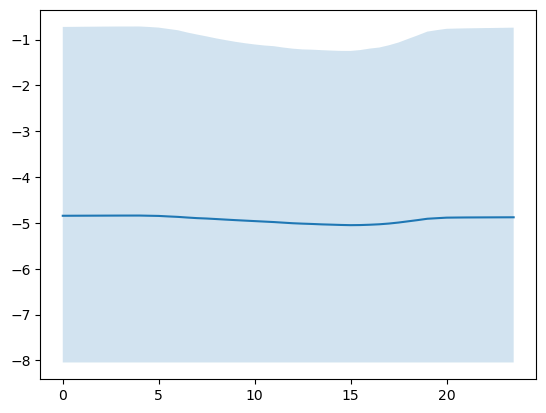

In [62]:
var = 'psiLeaf'
plt.plot(np.arange(0, 24, 0.5),dfm[var])
plt.fill_between(np.arange(0, 24, 0.5), dfql[var],dfqu[var], alpha=0.2)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

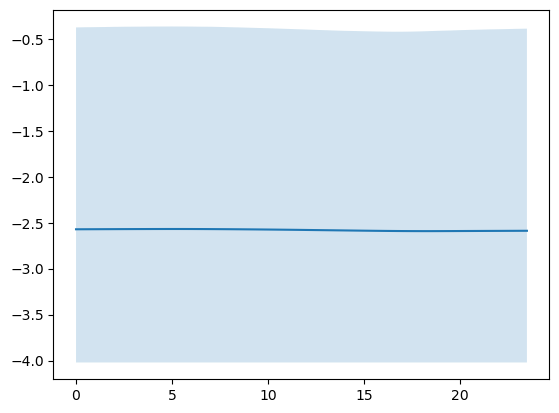

In [63]:
var = 'psiSap'
plt.plot(np.arange(0, 24, 0.5),dfm[var])
plt.fill_between(np.arange(0, 24, 0.5), dfql[var],dfqu[var], alpha=0.2)

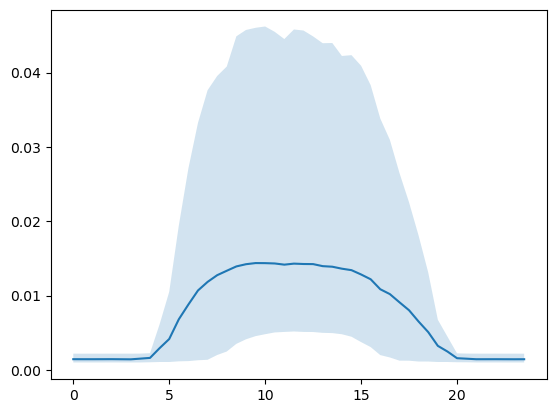

In [37]:
plt.plot(np.arange(0, 24, 0.5),dfm['gss'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['gss'],dfqu['gss'], alpha=0.2)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

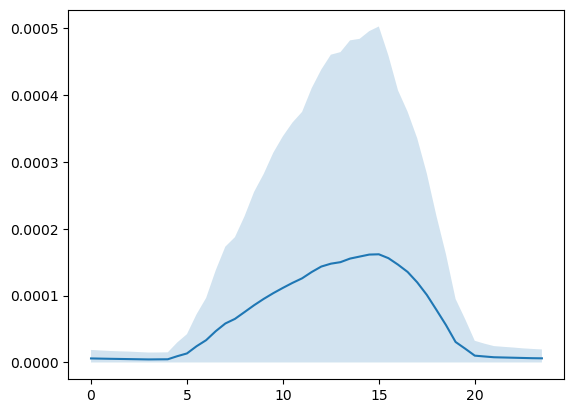

In [64]:
plt.plot(np.arange(0, 24, 0.5),dfm['T'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['T'],dfqu['T'], alpha=0.2)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

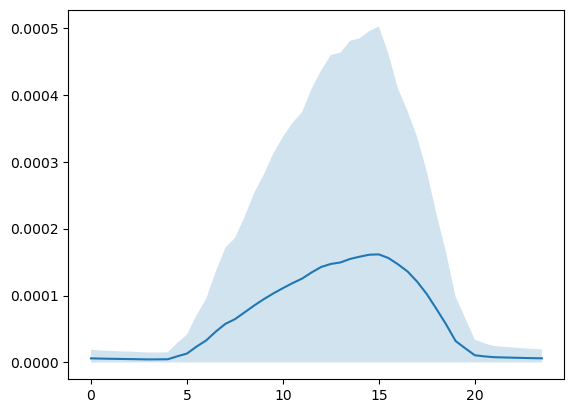

In [65]:
plt.plot(np.arange(0, 24, 0.5),dfm['J'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['J'],dfqu['J'], alpha=0.2)

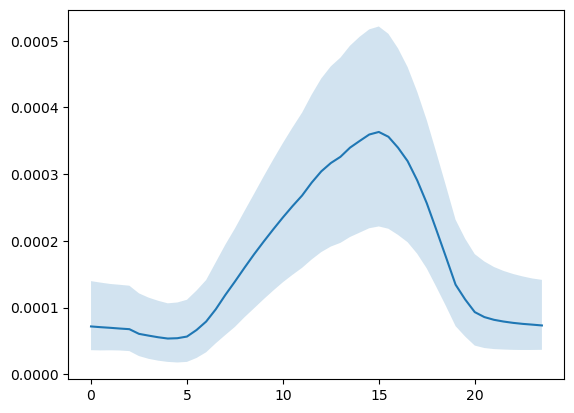

In [12]:
plt.plot(np.arange(0, 24, 0.5),dfm['G'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['G'],dfqu['G'], alpha=0.2)

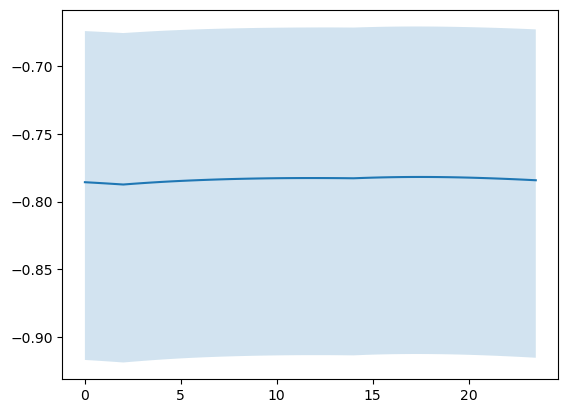

In [17]:
plt.fill_between(np.arange(0, 24, 0.5), dfql['psiSoilUp'], dfqu['psiSoilUp'], alpha=0.2)
plt.plot(np.arange(0, 24, 0.5), dfm['psiSoilUp'])


In [20]:
for i in [2,4,5]:
    print(np.round(df_ax_ql[i]['rmse'].iloc[0],2))
    print(np.round(df_ax_m[i]['rmse'].iloc[0],2))
    print(np.round(df_ax_qu[i]['rmse'].iloc[0],2))
    print("")

0.42
0.45
0.5

2.19
2.32
2.45

0.59
0.62
0.65



(-7.0, 0.0)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

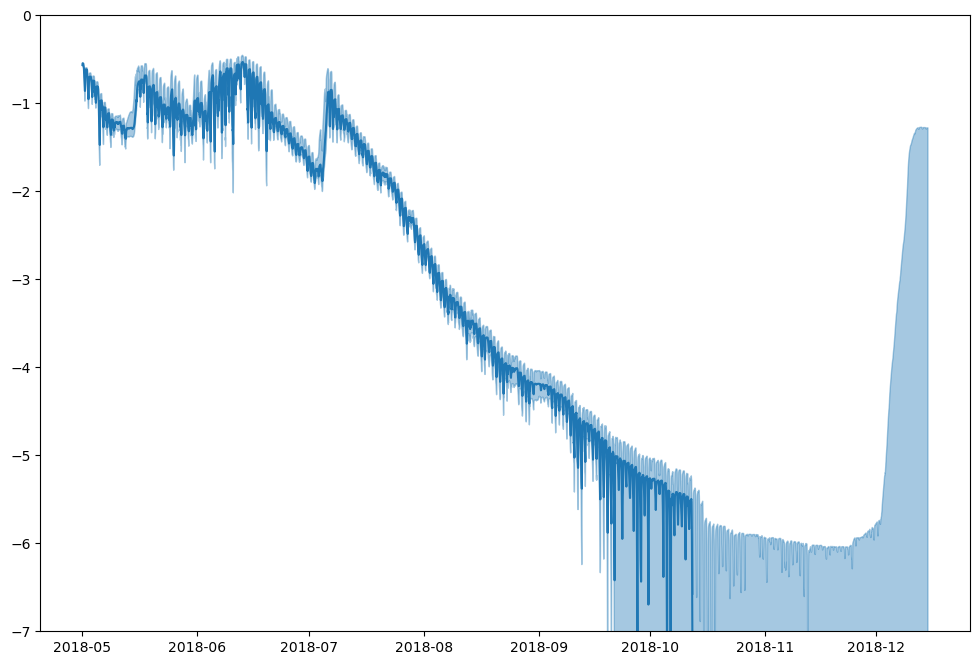

In [66]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(1,1, 1)
ax.plot(df_ax_m[2]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[2].index, df_ax_ql[2]['psiLeaf'], df_ax_qu[2]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ax.set_ylim(-7.0, 0)

In [ ]:
plt.rcParams["font.family"] = "Avenir"

"/User/homes/ppapastefanou/fonts/Avenir Next.ttc"

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

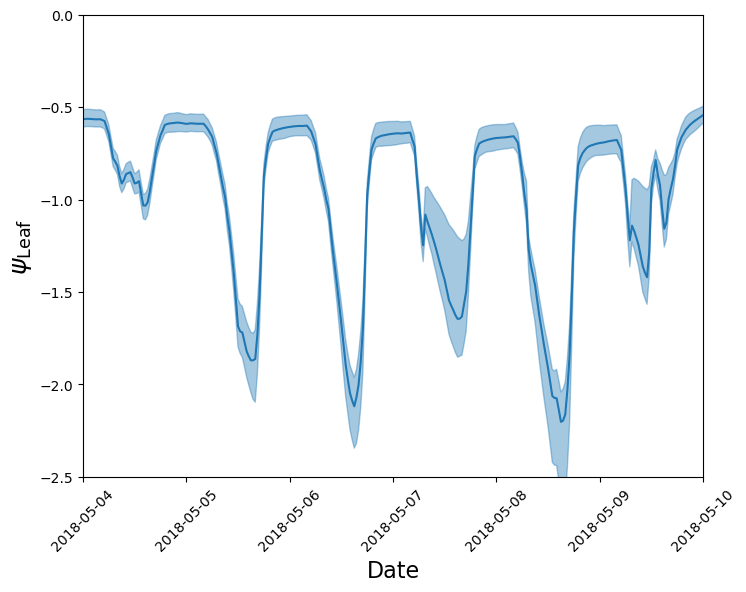

In [67]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-04'), pd.Timestamp('2018-05-10'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize = 18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P1.png"), bbox_inches='tight', dpi = 300)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

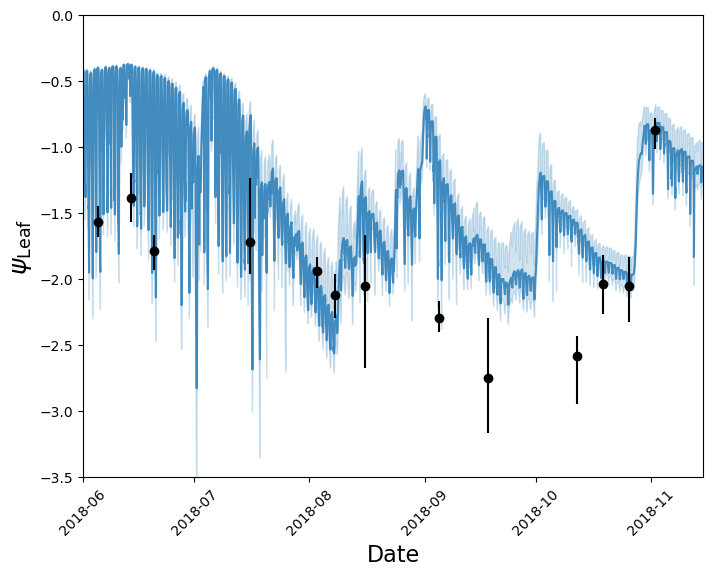

In [68]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:blue' ,alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:blue',
                alpha=0.2)
df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
df_tree_lower = trees[ii].groupby(trees[ii].index).min()
df_tree_upper = trees[ii].groupby(trees[ii].index).max()
ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                                       df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-11-15'))
plt.xticks(rotation=45)
ax.set_ylim(-3.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.savefig(os.path.join(post_path, "F1_P2.png"), bbox_inches='tight', dpi=300)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

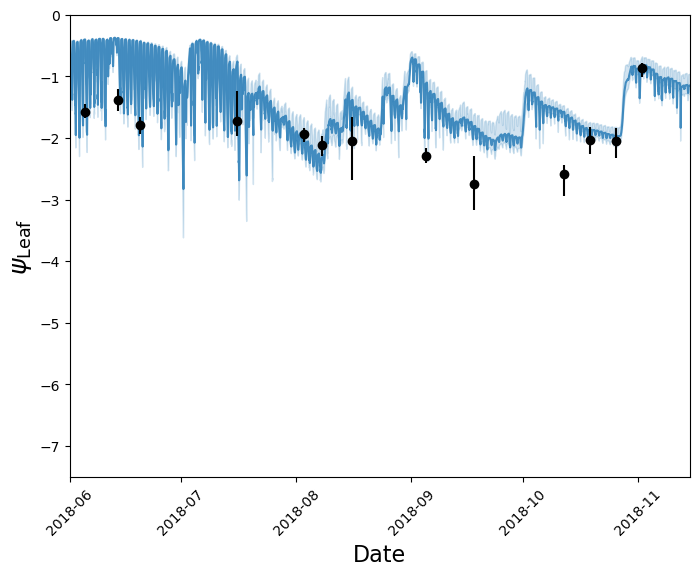

In [69]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:blue' ,alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:blue',
                alpha=0.2)
df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
df_tree_lower = trees[ii].groupby(trees[ii].index).min()
df_tree_upper = trees[ii].groupby(trees[ii].index).max()
ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                                       df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-11-15'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P3.png"), bbox_inches='tight', dpi=300)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

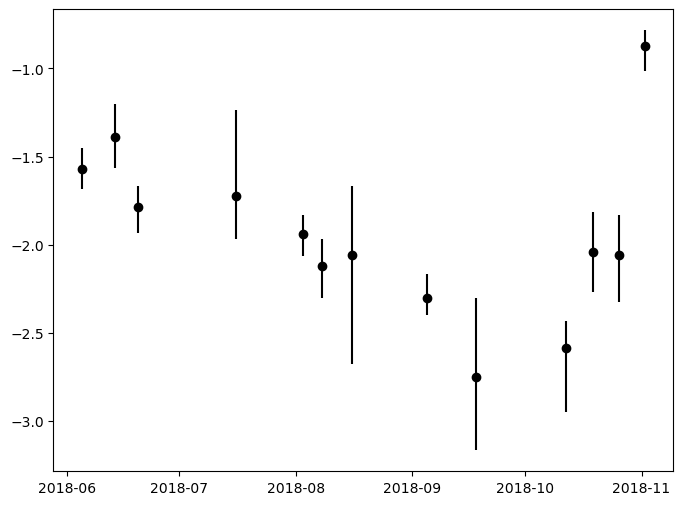

In [57]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
df_tree_lower = trees[ii].groupby(trees[ii].index).min()
df_tree_upper = trees[ii].groupby(trees[ii].index).max()
ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                                       df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
plt.show()

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

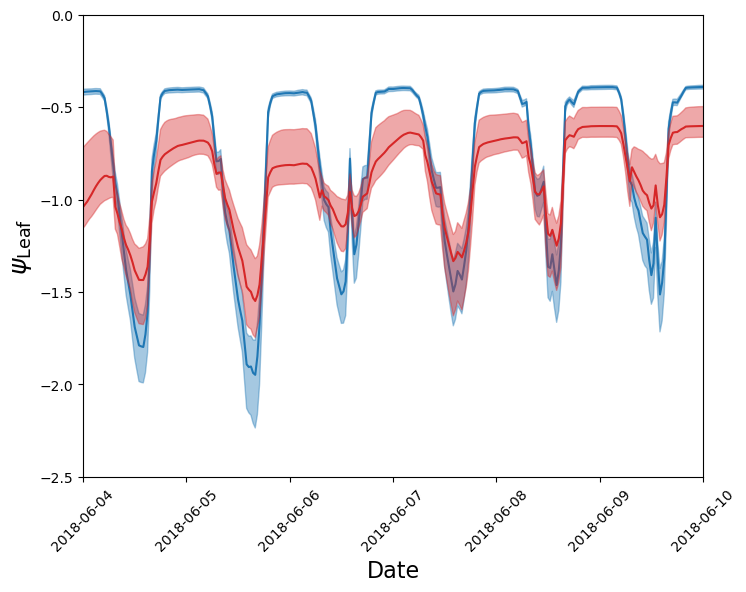

In [70]:

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ii = 2
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:red' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-06-04'), pd.Timestamp('2018-06-10'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P4.png"), bbox_inches='tight', dpi=300)

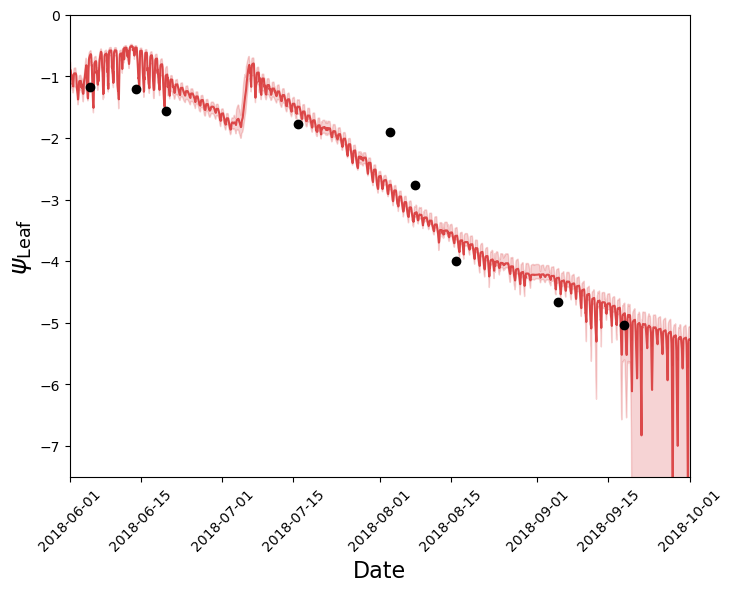

In [45]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P5.png"), bbox_inches='tight', dpi=300)

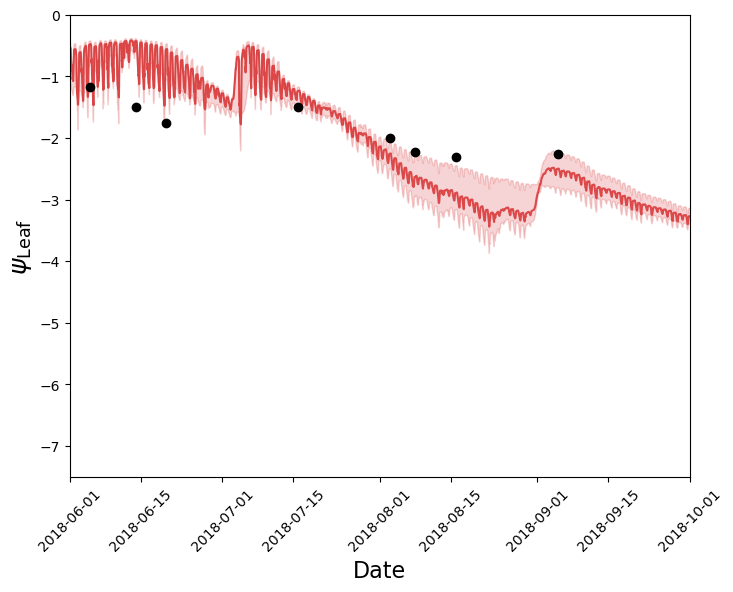

In [46]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 3
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P6.png"), bbox_inches='tight', dpi=300)

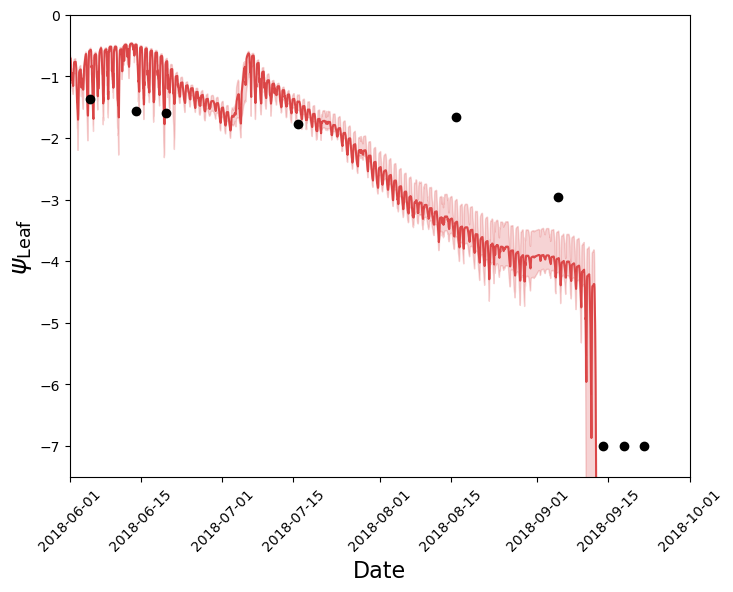

In [47]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 4
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P6.png"), bbox_inches='tight', dpi=300)


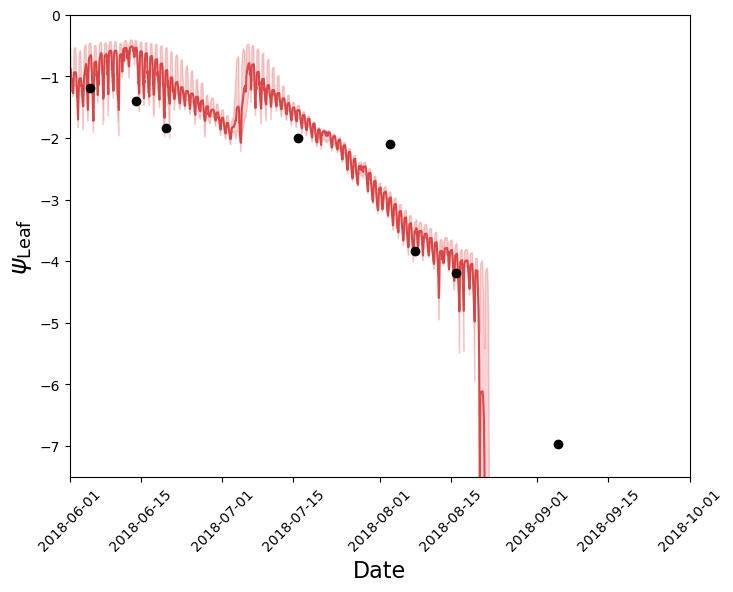

In [48]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P7.png"), bbox_inches='tight', dpi=300)

KeyError: 6

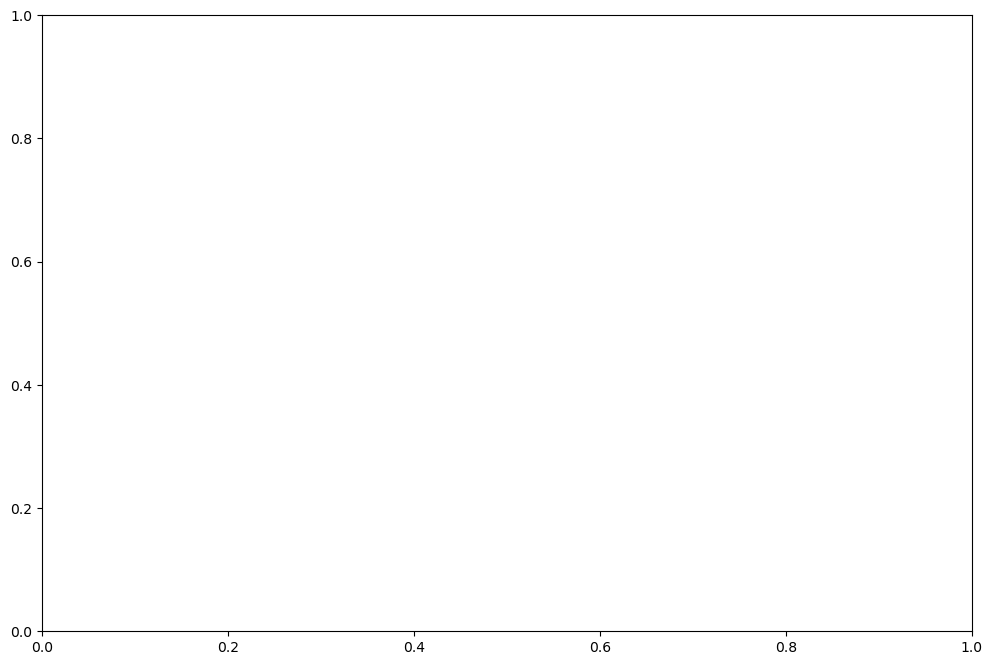

In [19]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(1,1, 1)
ii = 6
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:red' ,alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-8, 0)

(-8.0, 0.0)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

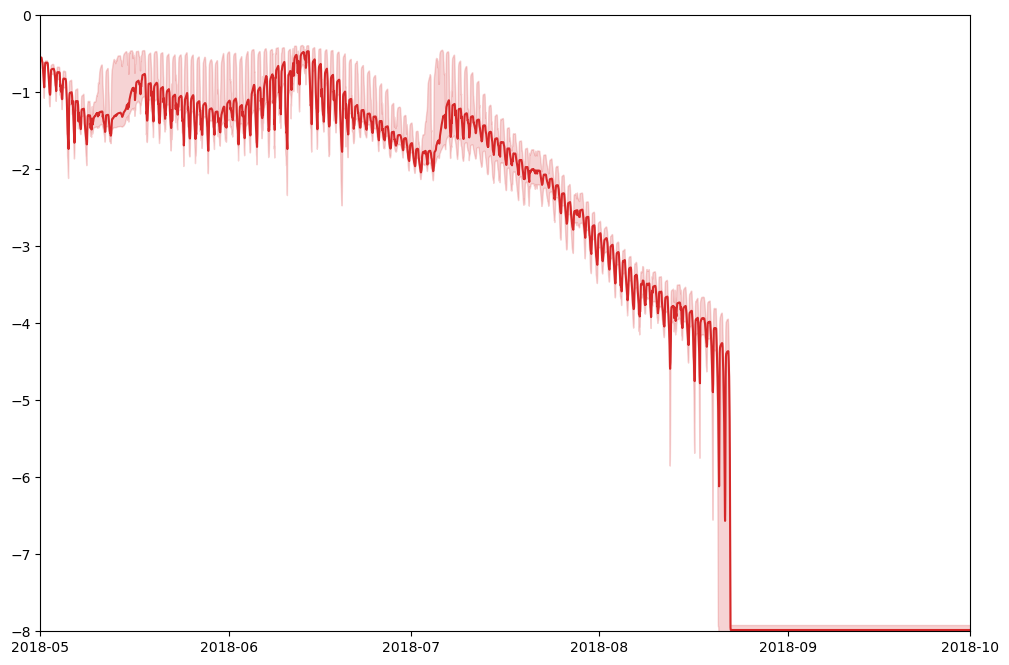

In [26]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(1,1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:red' ,alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-8, 0)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

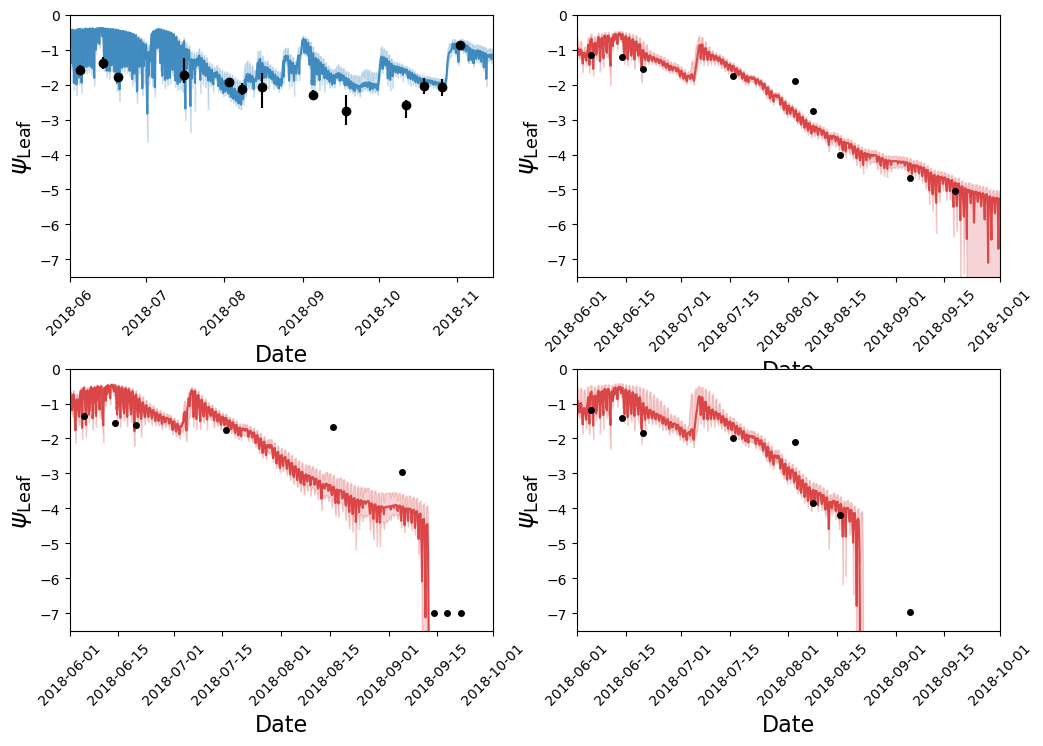

In [71]:
fig = plt.figure(figsize=(12, 8))


for i, ii in zip(range(1,5),[1,2,4,5]):
    if ii == 1:
        col = 'tab:blue'
    else:
        col = 'tab:red'
    ax = fig.add_subplot(2, 2, i)
    ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c=col, alpha=0.8)
    ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color=col,
                    alpha=0.2)
    if ii == 1:
        df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
        df_tree_lower = trees[ii].groupby(trees[ii].index).min()
        df_tree_upper = trees[ii].groupby(trees[ii].index).max()
        ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                        df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
    
    else:
        ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2, s =16)
    if ii == 1:
        ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-11-15'))
    else:
        ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
    ax.set_ylim(-7.5, 0)
    ax.set_xlabel("Date", fontsize=16)
    ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
    plt.xticks(rotation=45)
plt.subplots_adjust(hspace=0.35)
plt.savefig(os.path.join(post_path, "F1_ALL.png"), bbox_inches='tight', dpi=300)

(array([17655., 17656., 17657., 17658., 17659., 17660., 17661.]),
 [Text(17655.0, 0, '2018-05-04'),
  Text(17656.0, 0, '2018-05-05'),
  Text(17657.0, 0, '2018-05-06'),
  Text(17658.0, 0, '2018-05-07'),
  Text(17659.0, 0, '2018-05-08'),
  Text(17660.0, 0, '2018-05-09'),
  Text(17661.0, 0, '2018-05-10')])

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

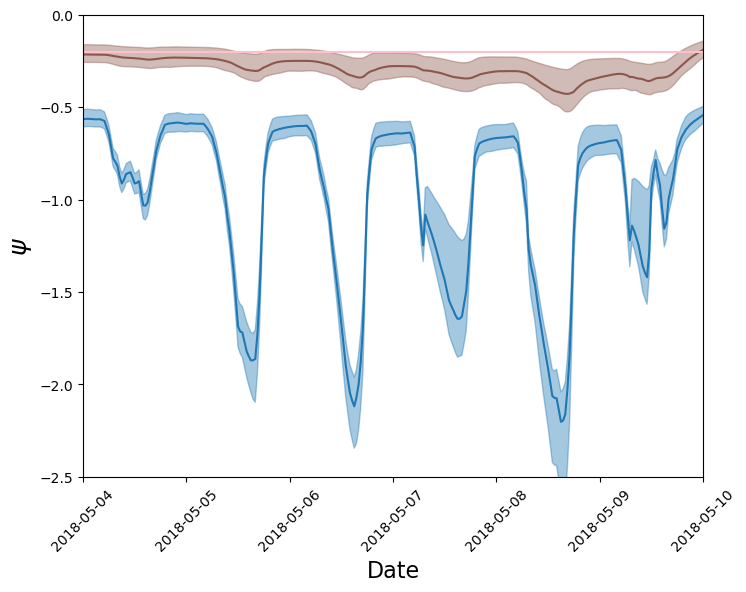

In [72]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ax.plot(df_ax_m[ii]['psiSap'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiSap'], df_ax_qu[ii]['psiSap'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.plot(df_ax_m[ii]['psiHeart'], zorder =1, c = 'pink')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiHeart'], df_ax_qu[ii]['psiHeart'], zorder =1, color = 'pink' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-04'), pd.Timestamp('2018-05-10'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)
#plt.savefig(os.path.join(post_path, "F1_P1.png"), bbox_inches='tight', dpi = 300)

(-8.0, 0.0)

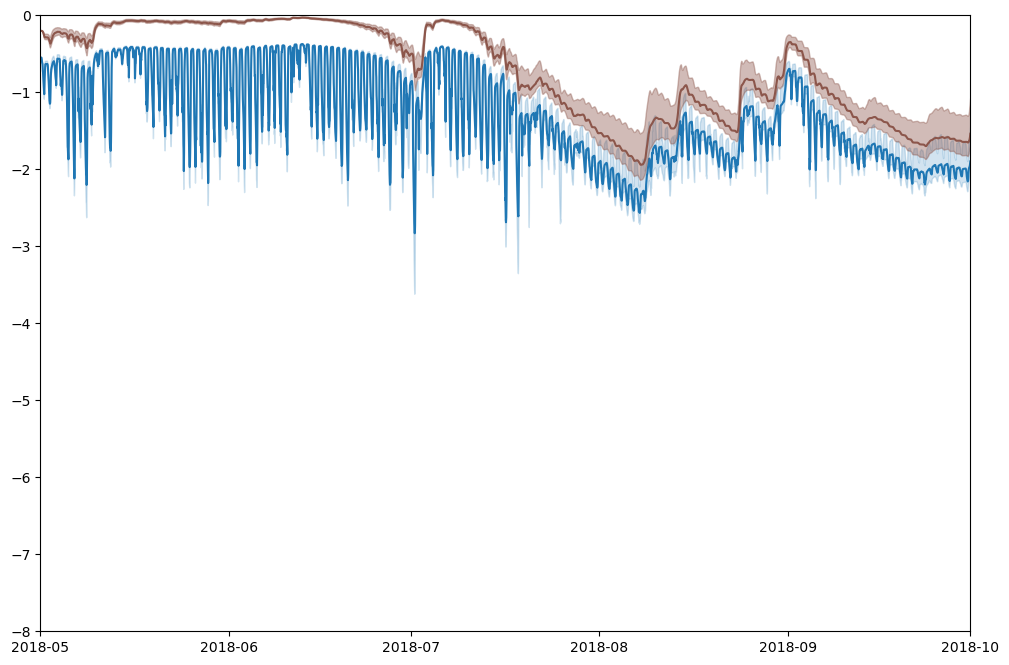

In [28]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:blue',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiSap'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiSap'], df_ax_qu[ii]['psiSap'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-8, 0)

(-10.0, 0.0)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

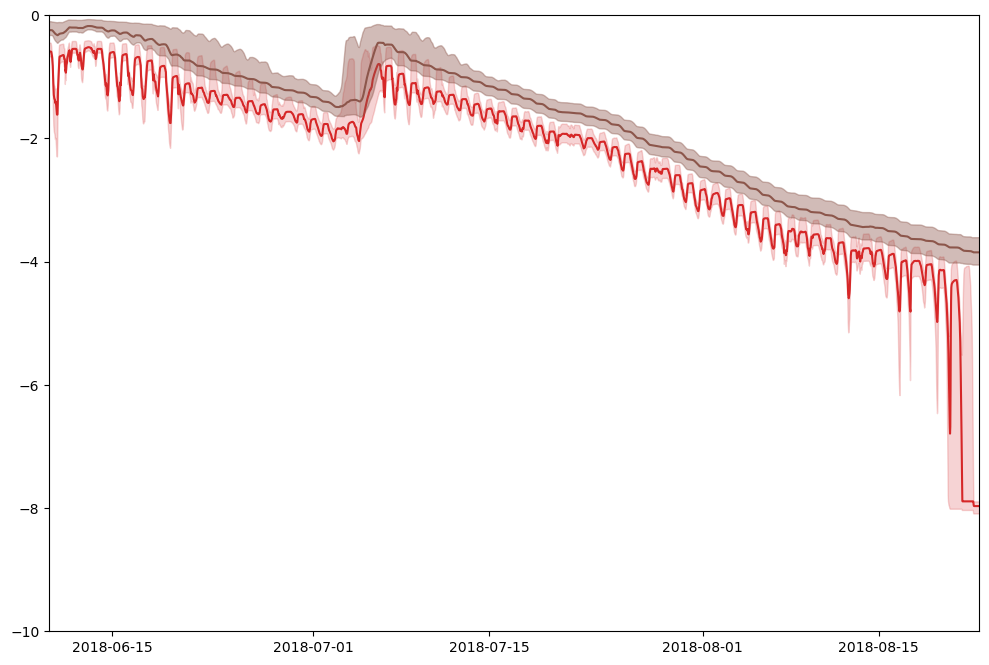

In [73]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiSap'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiSap'], df_ax_qu[ii]['psiSap'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-06-10'), pd.Timestamp('2018-8-23'))
ax.set_ylim(-10, 0)

(-10.0, 0.0)

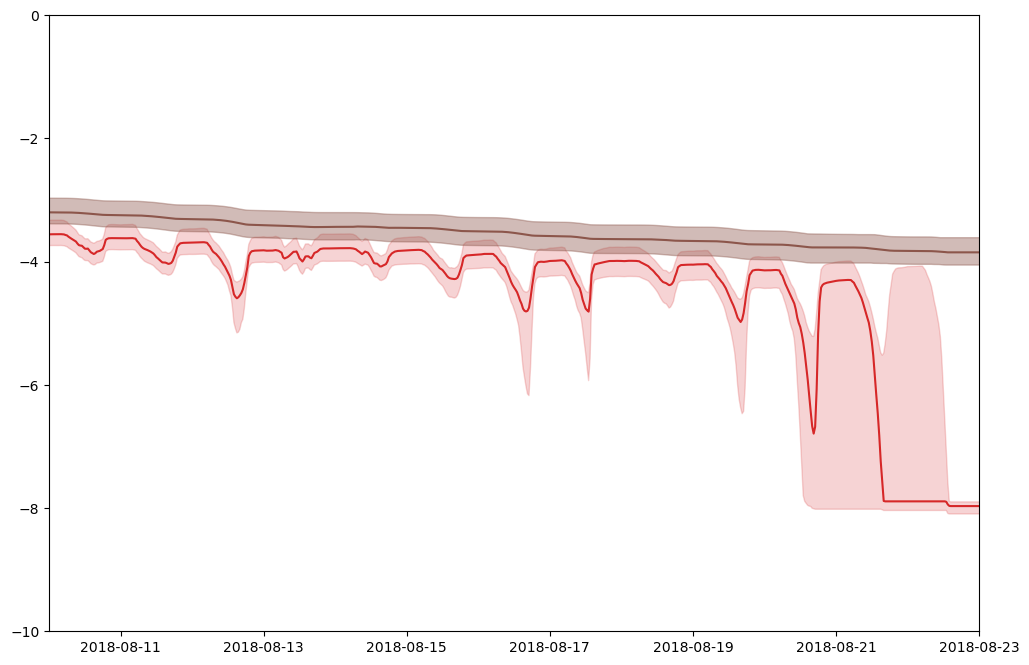

In [29]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiSap'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiSap'], df_ax_qu[ii]['psiSap'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-08-10'), pd.Timestamp('2018-8-23'))
ax.set_ylim(-10, 0)

(array([17720., 17727., 17734., 17744., 17751., 17758., 17765., 17775.,
        17782.]),
 [Text(17720.0, 0, '2018-07-08'),
  Text(17727.0, 0, '2018-07-15'),
  Text(17734.0, 0, '2018-07-22'),
  Text(17744.0, 0, '2018-08-01'),
  Text(17751.0, 0, '2018-08-08'),
  Text(17758.0, 0, '2018-08-15'),
  Text(17765.0, 0, '2018-08-22'),
  Text(17775.0, 0, '2018-09-01'),
  Text(17782.0, 0, '2018-09-08')])

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

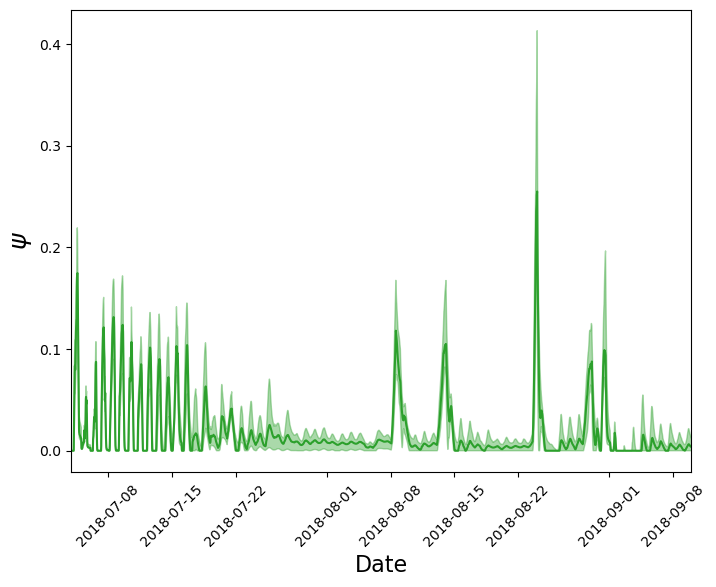

In [30]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['Gs'], zorder =1, c = 'tab:green')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['Gs'], df_ax_qu[ii]['Gs'], zorder = 1, color = 'tab:green' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-07-04'), pd.Timestamp('2018-09-10'))
#ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

(array([17652., 17666., 17683., 17697., 17713., 17727., 17744., 17758.,
        17775.]),
 [Text(17652.0, 0, '2018-05-01'),
  Text(17666.0, 0, '2018-05-15'),
  Text(17683.0, 0, '2018-06-01'),
  Text(17697.0, 0, '2018-06-15'),
  Text(17713.0, 0, '2018-07-01'),
  Text(17727.0, 0, '2018-07-15'),
  Text(17744.0, 0, '2018-08-01'),
  Text(17758.0, 0, '2018-08-15'),
  Text(17775.0, 0, '2018-09-01')])

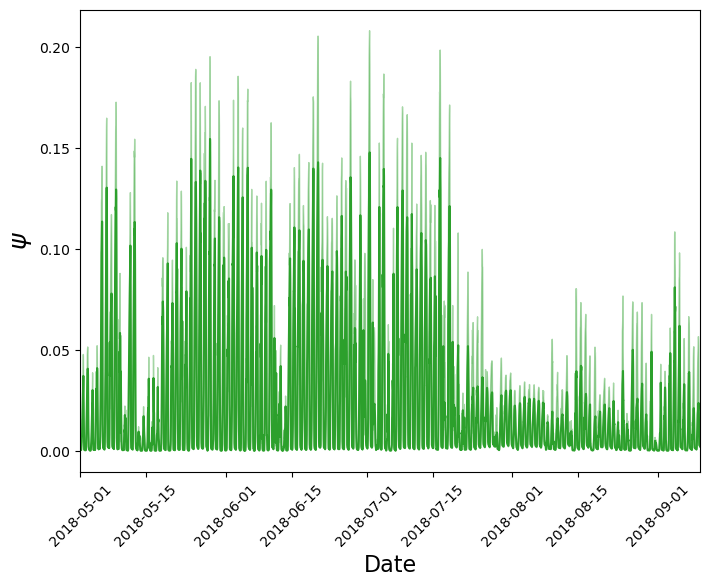

In [30]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['Js'], zorder =1, c = 'tab:green')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['Js'], df_ax_qu[ii]['Js'], zorder = 1, color = 'tab:green' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-09-10'))
#ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

(array([17666., 17668., 17670., 17672., 17674., 17676., 17678., 17680.,
        17682., 17683.]),
 [Text(17666.0, 0, '2018-05-15'),
  Text(17668.0, 0, '2018-05-17'),
  Text(17670.0, 0, '2018-05-19'),
  Text(17672.0, 0, '2018-05-21'),
  Text(17674.0, 0, '2018-05-23'),
  Text(17676.0, 0, '2018-05-25'),
  Text(17678.0, 0, '2018-05-27'),
  Text(17680.0, 0, '2018-05-29'),
  Text(17682.0, 0, '2018-05-31'),
  Text(17683.0, 0, '2018-06-01')])

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

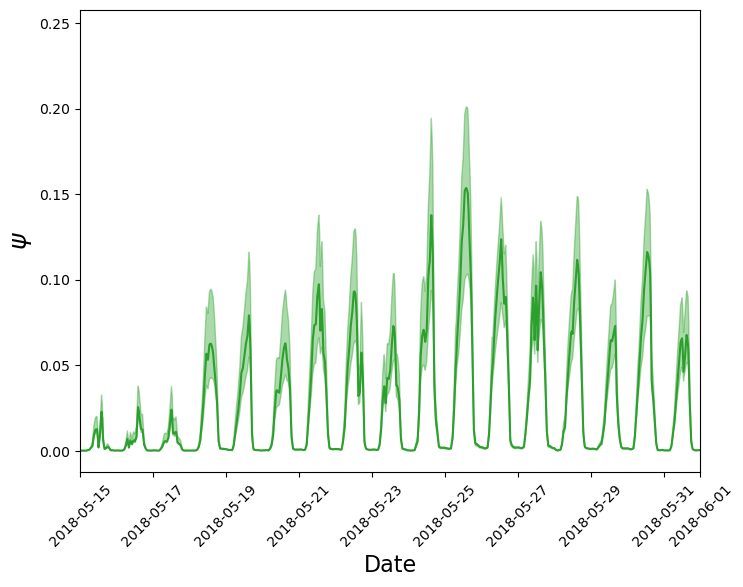

In [36]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 2
ax.plot(df_ax_m[ii]['Js'], zorder =1, c = 'tab:green')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['Js'], df_ax_qu[ii]['Js'], zorder = 1, color = 'tab:green' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-15'), pd.Timestamp('2018-06-1'))
#ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

In [ ]:
0.06 * 100/1000*18*1000

108.0

(-10.0, 0.0)

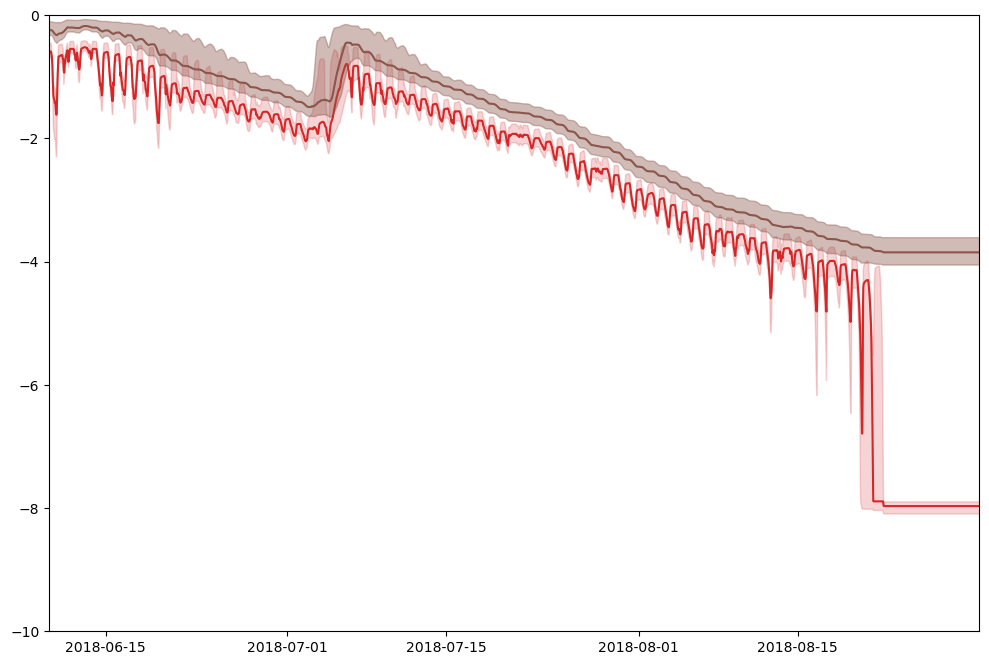

In [31]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiSap'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiSap'], df_ax_qu[ii]['psiSap'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-06-10'), pd.Timestamp('2018-8-31'))
ax.set_ylim(-10, 0)

(17727.0, 17774.0)

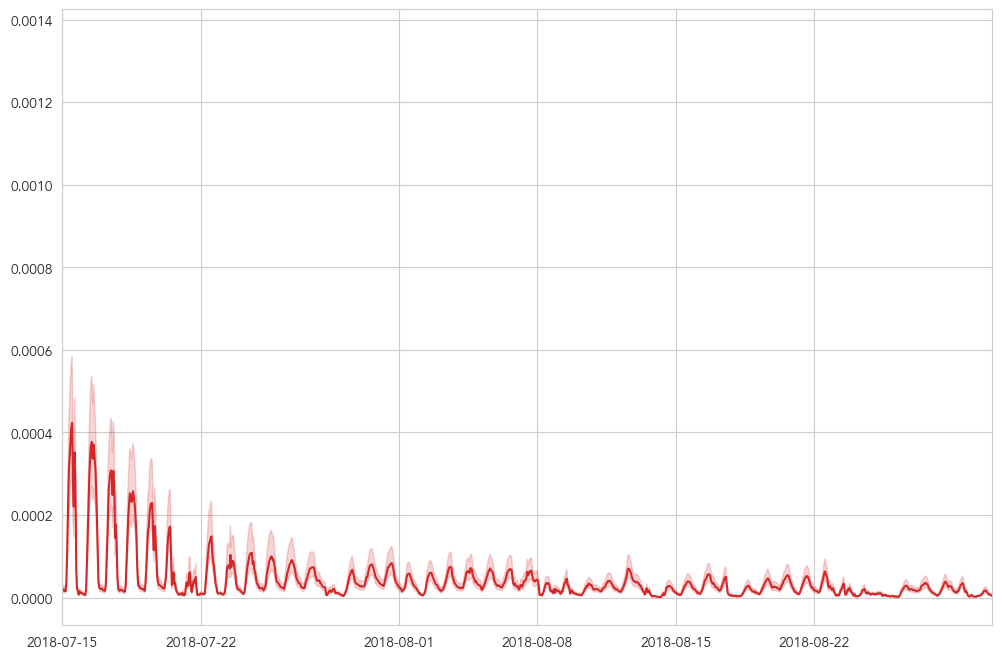

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['T'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['T'], df_ax_qu[ii]['T'], zorder=1, color='tab:red',
                alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-07-15'), pd.Timestamp('2018-8-31'))

(np.float64(17727.0), np.float64(17774.0))

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

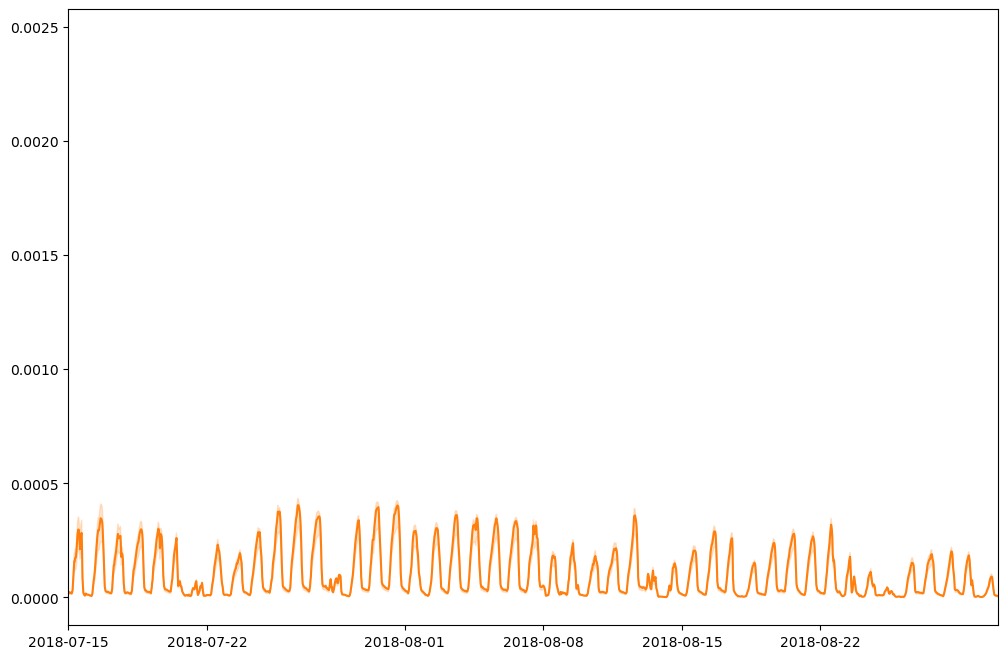

In [38]:
ax.set_ylim(-10, 0)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['J'], zorder=1, c='tab:orange')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['J'], df_ax_qu[ii]['J'], zorder=1, color='tab:orange',
                alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-07-15'), pd.Timestamp('2018-8-31'))

(17727.0, 17774.0)

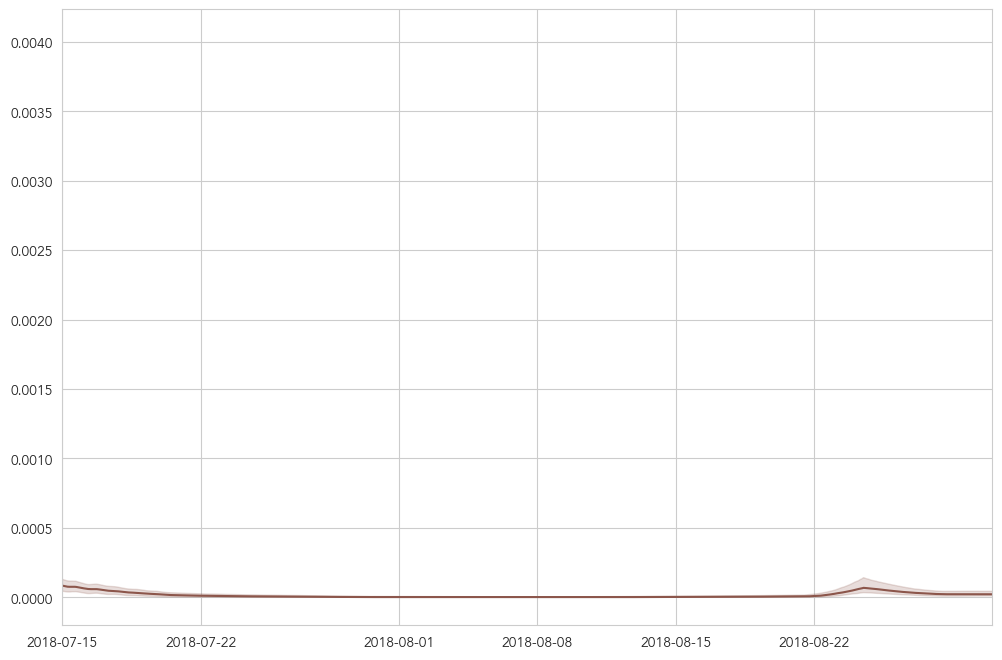

In [ ]:
ax.set_ylim(-10, 0)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['G'], zorder=1, c='tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['G'], df_ax_qu[ii]['G'], zorder=1, color='tab:brown',
                alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-07-15'), pd.Timestamp('2018-8-31'))

In [ ]:
df_ax_m[ii]['T'].mean()

7.204494153350238e-05

In [ ]:
df_ax_m[ii]['T']['2018-07-15':'2018-08-15'].mean()

5.199918513894749e-05

In [ ]:
ii=2
df_ax_m[ii]['vpd']['2018-08-1':'2018-09-01'].mean()

1000.6303757727146

In [ ]:
ii = 2
df_ax_m[ii]['gss']['2018-08-01':'2018-09-01'].mean()

0.0023696906864643097

In [ ]:
ii = 2
df_ax_m[ii]['T']['2018-08-01':'2018-09-01'].mean()

2.3407545689302367e-05

In [ ]:
ii = 2
df_ax_m[ii]['gss']['2018-08-01':'2018-09-01'].mean()

0.0023696906864643097

In [ ]:
ii = 2
df_ax_m[ii]['psiLeaf']['2018-08-01'].min()-df_ax_m[ii]['psiLeaf']['2018-09-01'].min()

1.2117869853973389

In [ ]:
1.2486491203308105 / 31

0.04027900388163905

In [ ]:
ii = 5
df_ax_m[ii]['psiLeaf']['2018-08-01'].min() - df_ax_m[ii]['psiLeaf']['2018-08-15'].min()

1.455795168876648

In [ ]:
1.455795168876648/15

0.09705301125844319

In [ ]:
ii=2
df_ax_m[ii]['vpd']['2018-08-1':'2018-08-15'].mean()

1280.0490270879534